Testing Edge Detection

📷 Testing with image: 2888723a-fd6f-4471-b7e5-692727bd5692_668bc6dbe4b48.jpg
   Image shape: (1717, 3162, 3)
   Edge image shape: (1717, 3162, 3)
   Edge mask shape: (1717, 3162)


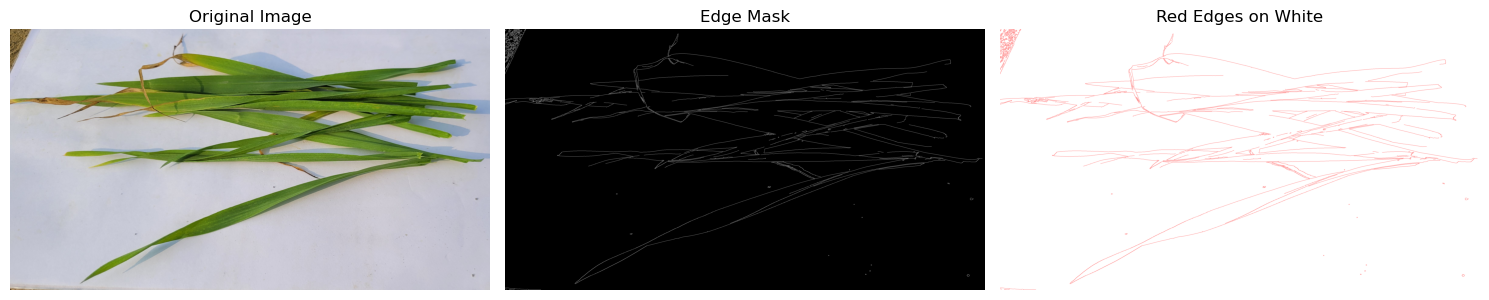


✅ Edge detection test successful!

Saving EdgeDetector class
✅ Saved EdgeDetector to utils/edge_detection.py

Verifying EdgeDetector class
✅ EdgeDetector class verified!
   Output shape: (100, 100, 3)
   Edge mask shape: (100, 100)
   Edge mask unique values: [  0 255]

🎉 Edge Detection setup complete!

📝 NOTE: The EdgeDetector class has been saved to utils/edge_detection.py
   It can be imported and used in the main application.


In [3]:
# %% [markdown]
# # Step 3: Test Edge Detection

# %%
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys  # Add missing sys import
# %%
# Define EdgeDetector class
class EdgeDetector:
    def __init__(self, threshold1=50, threshold2=150):
        self.threshold1 = threshold1
        self.threshold2 = threshold2
    
    def detect_edges(self, image):
        """
        Detect edges and highlight them in red on white background
        """
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        
        # Apply Gaussian blur
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Canny edge detection
        edges = cv2.Canny(blurred, self.threshold1, self.threshold2)
        
        # Create white background with red edges
        edge_image = np.ones((edges.shape[0], edges.shape[1], 3), dtype=np.uint8) * 255
        edge_image[edges != 0] = [255, 0, 0]  # Red edges
        
        return edge_image, edges

# %%
# Helper function to get a test image from the project
def get_test_image():
    """Get the first image from static/uploads folder or create a dummy image"""
    # First, check static/uploads folder for existing images
    upload_folder = os.path.join(os.getcwd(), 'static', 'uploads')
    if os.path.exists(upload_folder):
        images = [f for f in os.listdir(upload_folder) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif'))]
        if images:
            return os.path.join(upload_folder, images[0])
    
    # If no images found, check if there's a sample image in test_output
    test_output = os.path.join(os.getcwd(), 'test_output')
    if os.path.exists(test_output):
        images = [f for f in os.listdir(test_output) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            return os.path.join(test_output, images[0])
    
    # If no images found, return None (will use dummy image)
    return None

# %%
# Test edge detection
print("="*50)
print("Testing Edge Detection")
print("="*50)

# Get test image from project folders
test_image_path = get_test_image()

if test_image_path and os.path.exists(test_image_path):
    print(f"\n📷 Testing with image: {os.path.basename(test_image_path)}")
    
    # Read image
    image = cv2.imread(test_image_path)
    if image is None:
        print("❌ Could not read image, creating dummy image for testing...")
        # Create dummy image
        dummy_image = np.zeros((500, 500, 3), dtype=np.uint8)
        dummy_image[:, :] = [100, 150, 200]  # Light blue background
        # Draw a green square in the center (simulating leaf)
        cv2.rectangle(dummy_image, (150, 150), (350, 350), (0, 255, 0), -1)
        # Add some texture inside the square
        cv2.rectangle(dummy_image, (200, 200), (300, 300), (0, 200, 0), -1)
        image = dummy_image
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        print("   Using dummy image for testing")
    else:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        print(f"   Image shape: {image_rgb.shape}")
    
    # Initialize edge detector
    edge_detector = EdgeDetector()
    
    # Detect edges
    edge_image, edges = edge_detector.detect_edges(image_rgb)
    
    print(f"   Edge image shape: {edge_image.shape}")
    print(f"   Edge mask shape: {edges.shape}")
    
    # Display results
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Mask")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(edge_image)
    plt.title("Red Edges on White")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Edge detection test successful!")
    
else:
    print("\n⚠️ No test image found in static/uploads/ or test_output/")
    print("   Creating dummy image for testing...")
    
    # Create a dummy image for testing
    dummy_image = np.zeros((500, 500, 3), dtype=np.uint8)
    dummy_image[:, :] = [100, 150, 200]  # Light blue background
    
    # Draw a green square in the center (simulating leaf)
    cv2.rectangle(dummy_image, (150, 150), (350, 350), (0, 255, 0), -1)
    # Add some texture inside the square
    cv2.rectangle(dummy_image, (200, 200), (300, 300), (0, 200, 0), -1)
    # Add some random noise for more realistic edges
    noise = np.random.randint(0, 30, (500, 500, 3), dtype=np.uint8)
    dummy_image = cv2.addWeighted(dummy_image, 0.9, noise, 0.1, 0)
    
    image_rgb = cv2.cvtColor(dummy_image, cv2.COLOR_BGR2RGB)
    
    # Initialize edge detector
    edge_detector = EdgeDetector()
    
    # Detect edges
    edge_image, edges = edge_detector.detect_edges(image_rgb)
    
    print(f"   Created dummy image shape: {image_rgb.shape}")
    print(f"   Edge image shape: {edge_image.shape}")
    print(f"   Edge mask shape: {edges.shape}")
    
    # Display results
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Dummy Image (Simulated Leaf)")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Mask")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(edge_image)
    plt.title("Red Edges on White")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Edge detection test successful with dummy image!")

# %%
# Save EdgeDetector class to file
print("\n" + "="*50)
print("Saving EdgeDetector class")
print("="*50)

edge_detector_code = '''
import cv2
import numpy as np

class EdgeDetector:
    def __init__(self, threshold1=50, threshold2=150):
        """
        Initialize Edge Detector
        
        Args:
            threshold1: First threshold for Canny edge detection
            threshold2: Second threshold for Canny edge detection
        """
        self.threshold1 = threshold1
        self.threshold2 = threshold2
    
    def detect_edges(self, image):
        """
        Detect edges and highlight them in red on white background
        
        Args:
            image: Input image (RGB numpy array)
            
        Returns:
            edge_image: Image with red edges on white background
            edges: Binary edge mask
        """
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        
        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Canny edge detection
        edges = cv2.Canny(blurred, self.threshold1, self.threshold2)
        
        # Create white background with red edges
        edge_image = np.ones((edges.shape[0], edges.shape[1], 3), dtype=np.uint8) * 255
        edge_image[edges != 0] = [255, 0, 0]  # Red edges
        
        return edge_image, edges
    
    def adjust_thresholds(self, threshold1, threshold2):
        """
        Adjust the edge detection thresholds
        """
        self.threshold1 = threshold1
        self.threshold2 = threshold2
        print(f"Thresholds updated: threshold1={threshold1}, threshold2={threshold2}")
'''

# Ensure utils directory exists
os.makedirs('utils', exist_ok=True)

with open('utils/edge_detection.py', 'w', encoding='utf-8') as f:
    f.write(edge_detector_code)
print("✅ Saved EdgeDetector to utils/edge_detection.py")

# %%
# Quick verification
print("\n" + "="*50)
print("Verifying EdgeDetector class")
print("="*50)

try:
    # Import the saved class
    sys.path.append(os.path.join(os.getcwd(), 'utils'))
    from edge_detection import EdgeDetector
    
    # Test with dummy image
    test_dummy = np.zeros((100, 100, 3), dtype=np.uint8)
    test_dummy[30:70, 30:70] = [255, 255, 255]
    
    detector = EdgeDetector()
    edge_img, edge_mask = detector.detect_edges(test_dummy)
    
    print(f"✅ EdgeDetector class verified!")
    print(f"   Output shape: {edge_img.shape}")
    print(f"   Edge mask shape: {edge_mask.shape}")
    print(f"   Edge mask unique values: {np.unique(edge_mask)}")
    
except Exception as e:
    print(f"❌ Verification failed: {e}")

print("\n" + "="*50)
print("🎉 Edge Detection setup complete!")
print("="*50)
print("\n📝 NOTE: The EdgeDetector class has been saved to utils/edge_detection.py")
print("   It can be imported and used in the main application.")